# Week 3 - Visualization of Text Distributions

In [85]:
import os
import string
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import nltk

In [ ]:
# Download NLTK stopwords the first time
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [87]:
# 1. Load all .txt files in a folder, return list of strings
def load_corpus(folder_path):
    texts = []
    for fname in os.listdir(folder_path):
        path = os.path.join(folder_path, fname)
        if fname.endswith('.txt'):
            with open(path, 'r', encoding='utf-8') as f:
                content = f.read().strip()
                if "Abstract Unavailable" not in content and content:
                    texts.append(content)
    return texts

# 2. Tokenize and preprocess (lowercase, strip punctuation)
def preprocess_tokenize(text):
    tokens = word_tokenize(text.lower())
    # Remove punctuation-only tokens
    table = str.maketrans('', '', string.punctuation)
    tokens = [w.translate(table) for w in tokens if w.translate(table)]
    return tokens

# 3. Compute statistics
def compute_stats(tokens):
    num_tokens = len(tokens)
    num_types = len(set(tokens))
    hapax = [w for w, c in Counter(tokens).items() if c == 1]
    return {
        "num_tokens": num_tokens,
        "num_types": num_types,
        "hapax_legomena": len(hapax),
        "hapax_to_token_ratio": len(hapax) / num_tokens if num_tokens > 0 else 0,
        "type_to_token_ratio": num_types / num_tokens if num_tokens > 0 else 0,
    }

# 4. Plot Zipf's law
def plot_zipf(tokens):
    # Get word frequencies and sort by most common
    freq = Counter(tokens)
    sorted_freqs = np.array(sorted(freq.values(), reverse=True))
    ranks = np.arange(1, len(sorted_freqs) + 1)

    plt.figure(figsize=(9, 7))

    # PLot black circles (marker 'o', facecolor/edgecolor black)
    plt.scatter(ranks, sorted_freqs, color='black', edgecolors='grey', marker='o')

    # Plot the dashed Zipf reference line
    # According to Zipf's law, the frequency of a word is inversely proportional to its rank: f(r) = c / r^s --> C is the frequency of the most common word, r is the rank.
    # For the lowest rank 1: 1 = c / r^s --> s = log(c) / log(r), here s = 0.935
    # Under log-log-scale, we get a straight line log(f) = log(c) - s*log(r)
    x_min, x_max = ranks[0], ranks[-1]
    y_max, y_min = sorted_freqs[0], sorted_freqs[-1]
    # calculate a straight line in log-log space with slope -1
    ref_ranks = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    ref_freqs = y_max * ref_ranks ** (-0.935)
    plt.plot(ref_ranks, ref_freqs, 'k--', linewidth=1.4)

    # Set logarithmic axes
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel("log(Rank)", fontsize=14)
    plt.ylabel("log(Frequency)", fontsize=14)
    plt.title("Zipf's Law on the NeurIPS corpus", fontsize=18, fontweight='bold')

    # Remove grid for clarity, set ticks
    plt.grid(False)
    plt.tick_params(direction='out', length=6, width=1)

    # Add annotation with curved arrow
    plt.annotate('Perfect Zipfian Distribution',
                 xy=(ref_ranks[60], ref_freqs[60]),  # Point on the line to annotate
                 xytext=(5, 10),  # Text position
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5, headlength=8, connectionstyle='arc3,rad=0.2'),
                 fontsize=12,
                 fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
# Dataset of 10 randomly samples NeurIPS abstracts for 1987-2023
folder = "data/NeurIPS_Abstracts"

stop_words = set(stopwords.words('english'))
all_texts = load_corpus(folder)
all_texts

In [89]:
# Collect all tokens for the corpus
all_tokens = []
for text in all_texts:
    all_tokens.extend(preprocess_tokenize(text))


--- Lexicostatistics for the NeurIPS corpus ---
num_tokens: 74071
num_types: 7895
hapax_legomena: 3501
hapax_to_token_ratio: 0.047265461516652944
type_to_token_ratio: 0.10658692335731933

--- Statistics after stop-word filtering ---
num_tokens: 45487
num_types: 7779
hapax_legomena: 3494
hapax_to_token_ratio: 0.07681315540703937
type_to_token_ratio: 0.17101589465121902

Plotting Zipf's law for full corpus:


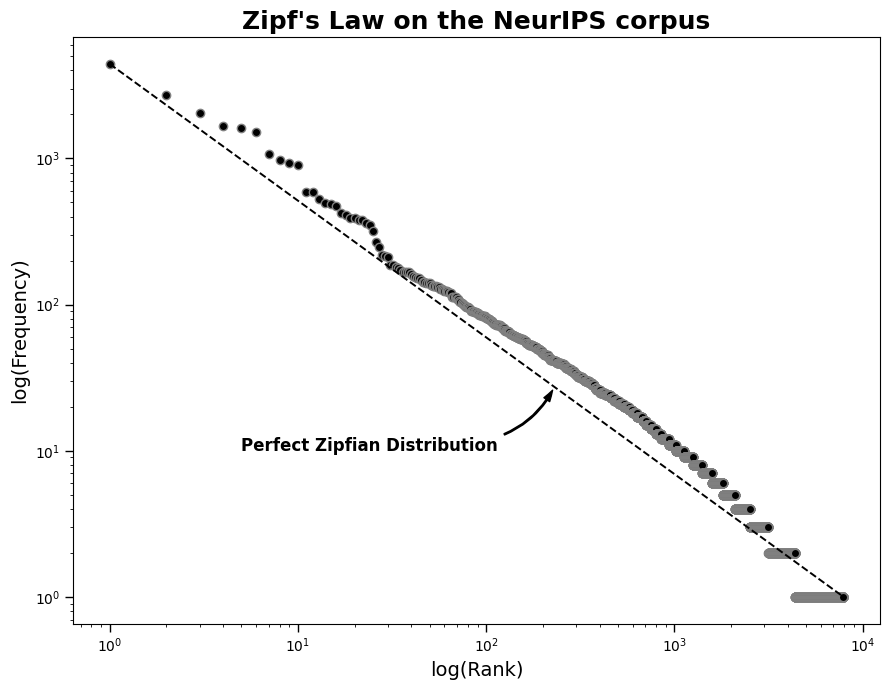

In [90]:
# Statistics for full corpus (with stopwords)
print("\n--- Lexicostatistics for the NeurIPS corpus ---")
stats_full = compute_stats(all_tokens)
for k, v in stats_full.items():
    print(f"{k}: {v}")

print("\n--- Statistics after stop-word filtering ---")
tokens_nostop = [tok for tok in all_tokens if tok not in stop_words]
stats_nostop = compute_stats(tokens_nostop)
for k, v in stats_nostop.items():
    print(f"{k}: {v}")

# Plot Zipf's law
print("\nPlotting Zipf's law for full corpus:")
plot_zipf(all_tokens)

## Aufgabe 1.1 (Hausaufgabe)
Wenden Sie den obigen Code auf einen eigenen Textdatensatz an, um die Visualisierung von frequency und rank im Vergleich zum Zipfschen Gesetz zu reproduzieren. Dieser sollte mindestens 10.000 Wörter/Tokens enthalten. Sie können auch einen Korpus verwenden, den Sie im Internet finden. Vergleichen Sie die Ergebnisse mit den Ergebnissen des NeurIPS-Korpus. Welche Unterschiede und Gemeinsamkeiten finden Sie auf einen Blick, wenn Sie die beiden Plots vergleichen? (Maximal 200 Wörter)

## Aufgabe 2
Starten Sie ins Miniprojekt!
Aufbauend auf den Vorlesungsinhalten sowie den Themengebieten, Datenquellen, Fragestellungen, Visualisierungen und ML-Techniken, welche wir gemeinsam in der Übung erarbeitet haben, entwerfen Sie alleine oder in Kleingruppen von 2-3 Personen einen Entwurf für Ihr Mini-Projekt.